# PC3236 $\cdot$ Computational Methods in Physics
### Parth Bhargava $\cdot$ A0310667E
## Assignment 2

### Problem 1: Least-squares fit of $I(\omega)$
We determine the parameters $a$ and $b$ in the model below so that the computed values of $I(\omega)$ best fit the 11 given data points in the least-squares sense.

### Equations to solve
The model is

$$
I(\omega) = \int_{0}^{\infty} \frac{e^{-x^{2}}}{\left(\omega - a/x\right)^{2} + b}\, dx,
$$

and the least-squares objective is

$$
S(a,b) = \sum_{i=1}^{11} \left[I(\omega_i; a,b) - I_i\right]^2.
$$

### Numerical method
- **Integral evaluation:** composite Simpson rule on $[0, x_{\max}]$ with $x_{\max}=8$ (the Gaussian makes the tail beyond this negligible). The point $x=0$ is handled with a tiny offset to avoid division by zero; the integrand itself remains finite because the denominator grows like $a^2/x^2$.
- **Least-squares minimization:** Newton’s method for systems, applied to $\nabla S(a,b)=0$. The gradient and Hessian of $S$ are computed by finite differences, and a short backtracking step is used if the full Newton step does not reduce $S$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

omega = np.array([0.0, 1.5, 3.0, 4.5, 6.0, 7.5, 9.0, 10.5, 12.0, 13.5, 15.0])
I_obs = np.array([0.0137, 0.0268, 0.0630, 0.1087, 0.1265, 0.1208, 0.1063, 0.0906, 0.0767, 0.0649, 0.0553])


def simpson_integral(y, h):
    return h / 3.0 * (y[0] + y[-1] + 4.0 * np.sum(y[1:-1:2]) + 2.0 * np.sum(y[2:-1:2]))


def I_model(w, a, b, n=6000, xmax=8.0):
    if n % 2 == 1:
        n += 1
    x = np.linspace(0.0, xmax, n + 1)
    x[0] = 1e-8
    denom = (w - a / x) ** 2 + b
    integrand = np.exp(-x**2) / denom
    h = xmax / n
    return simpson_integral(integrand, h)

In [3]:
def objective(params):
    a, b = params
    if b <= 0:
        return 1e9
    preds = np.array([I_model(w, a, b) for w in omega])
    return np.sum((preds - I_obs) ** 2)


def grad_hess_fd(f, p, h=1e-3):
    f0 = f(p)
    n = len(p)
    grad = np.zeros(n)
    H = np.zeros((n, n))
    for i in range(n):
        dp = np.zeros(n)
        dp[i] = h
        f1 = f(p + dp)
        f2 = f(p - dp)
        grad[i] = (f1 - f2) / (2.0 * h)
        H[i, i] = (f1 - 2.0 * f0 + f2) / (h**2)
        for j in range(i + 1, n):
            dq = np.zeros(n)
            dq[j] = h
            fpp = f(p + dp + dq)
            fpm = f(p + dp - dq)
            fmp = f(p - dp + dq)
            fmm = f(p - dp - dq)
            H[i, j] = (fpp - fpm - fmp + fmm) / (4.0 * h**2)
            H[j, i] = H[i, j]
    return grad, H


def newton_minimize(f, p0, tol=1e-8, max_iter=20):
    p = np.array(p0, dtype=float)
    history = []
    for _ in range(max_iter):
        g, H = grad_hess_fd(f, p)
        try:
            dp = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            dp = np.linalg.lstsq(H, -g, rcond=None)[0]
        f0 = f(p)
        step = 1.0
        while step > 1e-4:
            p_new = p + step * dp
            if p_new[1] <= 0:
                step *= 0.5
                continue
            if f(p_new) < f0:
                p = p_new
                break
            step *= 0.5
        history.append((p.copy(), f(p)))
        if np.linalg.norm(dp) < tol * (1.0 + np.linalg.norm(p)):
            break
    return p, history

### Initial guess
The data peak is near $\omega \approx 6$, so we start with $a_0 \approx 5.5$ and a moderate $b_0 \approx 1.5$ to capture the peak width.

Best-fit a = 5.500062
Best-fit b = 1.499802
Objective S = 7.631e-09
RMSE on data points = 2.634e-05


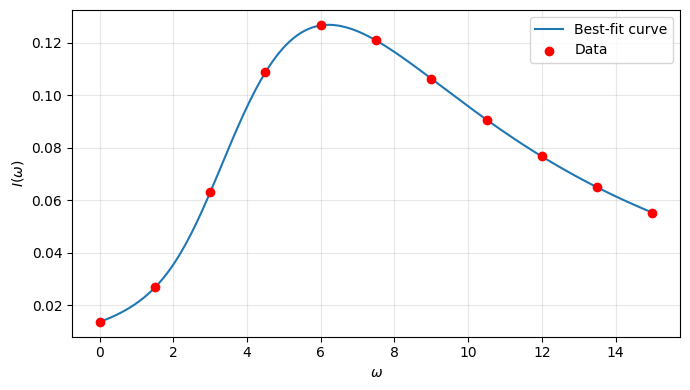

In [4]:
p0 = np.array([5.5, 1.5])
params, history = newton_minimize(objective, p0)
a_fit, b_fit = params

print(f"Best-fit a = {a_fit:.6f}")
print(f"Best-fit b = {b_fit:.6f}")
print(f"Objective S = {objective(params):.3e}")

omega_dense = np.linspace(0.0, 15.0, 200)
I_fit = np.array([I_model(w, a_fit, b_fit) for w in omega_dense])
I_fit_points = np.array([I_model(w, a_fit, b_fit) for w in omega])
rmse = np.sqrt(np.mean((I_fit_points - I_obs) ** 2))
print(f"RMSE on data points = {rmse:.3e}")

plt.figure(figsize=(7, 4))
plt.plot(omega_dense, I_fit, label="Best-fit curve")
plt.scatter(omega, I_obs, color="red", zorder=3, label="Data")
plt.xlabel(r"$\omega$")
plt.ylabel(r"$I(\omega)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Results
The printed values of $a$ and $b$ are the least-squares best fit. The plot overlays the fitted curve on the data for direct visual comparison.

### Short discussion
The fitted curve captures the rise and fall of the data across the full $\omega$ range. The Gaussian factor ensures the integral converges rapidly, so truncating the upper limit at $x_{\max}=8$ is sufficient for stable results; increasing $x_{\max}$ or the Simpson grid size changes $a$ and $b$ only in the final digits.